# Deep Learning for Molecular Property Prediction: A Comprehensive Guide

Welcome to this comprehensive deep learning tutorial! We'll explore how to build and train neural networks for predicting molecular properties, specifically solubility.

## What We'll Cover

1. **Setting up**
   - Install libraries and download data
   - Pytorch

1. **Data Understanding & Exploration**
   - Dataset analysis and visualization
   - Molecular descriptors
   - Data spliting

2. **Deep Learning Fundamentals**
   - What is a neural network?
   - Architecture components
   - Hyperparameters explanation

3. **Model Development**
   - Building a neural network from scratch
   - Training process understanding
   - Hyperparameter optimization using grid search

4. **Model Evaluation**
   - Performance metrics
   - Results analysis



# Deep Learning for Molecular Property Prediction: A Comprehensive Guide

Welcome to this comprehensive deep learning tutorial! We'll explore how to build and train neural networks for predicting molecular properties, specifically solubility.

## What We'll Cover

1. **Setting up**
   - Install libraries and download data
   - Pytorch

1. **Data Understanding & Exploration**
   - Dataset analysis and visualization
   - Molecular descriptors
   - Data spliting

2. **Deep Learning Fundamentals**
   - What is a neural network?
   - Architecture components
   - Hyperparameters explanation

3. **Model Development**
   - Building a neural network from scratch
   - Training process understanding
   - Hyperparameter optimization using grid search

4. **Model Evaluation**
   - Performance metrics
   - Results analysis



# Deep Learning for Molecular Property Prediction: A Comprehensive Guide

Welcome to this comprehensive deep learning tutorial! We'll explore how to build and train neural networks for predicting molecular properties, specifically solubility.

## What We'll Cover

1. **Setting up**
   - Install libraries and download data
   - Pytorch

1. **Data Understanding & Exploration**
   - Dataset analysis and visualization
   - Molecular descriptors
   - Data spliting

2. **Deep Learning Fundamentals**
   - What is a neural network?
   - Architecture components
   - Hyperparameters explanation

3. **Model Development**
   - Building a neural network from scratch
   - Training process understanding
   - Hyperparameter optimization using grid search

4. **Model Evaluation**
   - Performance metrics
   - Results analysis



# **1. Setting up**

### **Install libraries and download data**

In [ ]:
# Install all libraries
! pip install pytorch-lightning wandb rdkit ogb deepchem torch

# Download all data
! mkdir -p data/
# TODO: Download the ESOL dataset from https://acs.figshare.com/ndownloader/files/14790314 and save it to data/ as ESOL.txt


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


### **Pytorch**
#### What is Pytorch?
Based on the Torch library, PyTorch is one of the most popular deep learning frameworks for machine learning practitioners. We will learn to use PyTorch to do deep learning work. You can also browse the PyTorch [tutorials](https://pytorch.org/tutorials/) and [docs](https://pytorch.org/docs/stable/index.html) for additional details.

#### Pytorch Lightning
PyTorch Lightning is the deep learning framework for professional AI researchers and machine learning engineers who need maximal flexibility without sacrificing performance at scale. You can also browse its [documentation](https://pytorch-lightning.readthedocs.io/en/stable/) for additional details.

Let´s start by setting a random seed to ensure repeatability of experiments

In [ ]:
import random
import numpy as np
import torch

from pytorch_lightning import seed_everything

seed_everything(0)

# **2. Understanding Our Data**

## The ESOL Dataset
We're working with the [ESOL](https://acs.figshare.com/articles/dataset/ESOL_Estimating_Aqueous_Solubility_Directly_from_Molecular_Structure/7944677?file=14790314) (Estimated SOLubility) dataset, which contains:
- **Compound ID**: Unique identifier for each compound.
- **Measured log(solubility:mol/L)**: Experimental solubility values in log mol/L.
- **ESOL predicted log(solubility:mol/L)**: Predicted solubility values using the ESOL method.
- **SMILES**: Simplified Molecular Input Line Entry System representation of the molecular structure.

### What is SMILES?
SMILES (Simplified Molecular Input Line Entry System) is a line notation for describing the structure of chemical species using short ASCII strings. For example:
- `CC(=O)O` represents acetic acid (CH₃COOH)
- `C1=CC=CC=C1` represents benzene
- `O` represents water (H₂O)

Key SMILES syntax:
- Letters represent atoms (C=carbon, O=oxygen, N=nitrogen, etc.)
- Numbers indicate rings
- `=` represents double bonds
- `#` represents triple bonds
- Branching is shown with parentheses
- Square brackets `[]` are used for more complex cases

Here is an example of a molecule represented as SMILES
<div align="left">
    <figure>
        <img src="https://upload.wikimedia.org/wikipedia/commons/0/00/SMILES.png" alt="Molecule SMILES Example" width="400"/>
        <figcaption><i>Example of a molecule and its SMILES representation</i></figcaption>
    </figure>
</div>

### Why Solubility Prediction?
Solubility is a crucial property in drug development and chemical processes. Accurate prediction can:
- Speed up drug discovery
- Reduce experimental costs
- Help in formulation development

### Data Preprocessing
Let's start by exploring our data:



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

# TODO: Load ESOL data in a pandas dataframe keeping only "measured log" and "SMILES" columns
# then show the first 5 rows of your dataframe


### Visualization of Molecular Structures and Solubility

Now we will visualize some molecules from the dataset along with their solubility values. This will help us better understand the relationship between molecular structure and the property we want to predict.

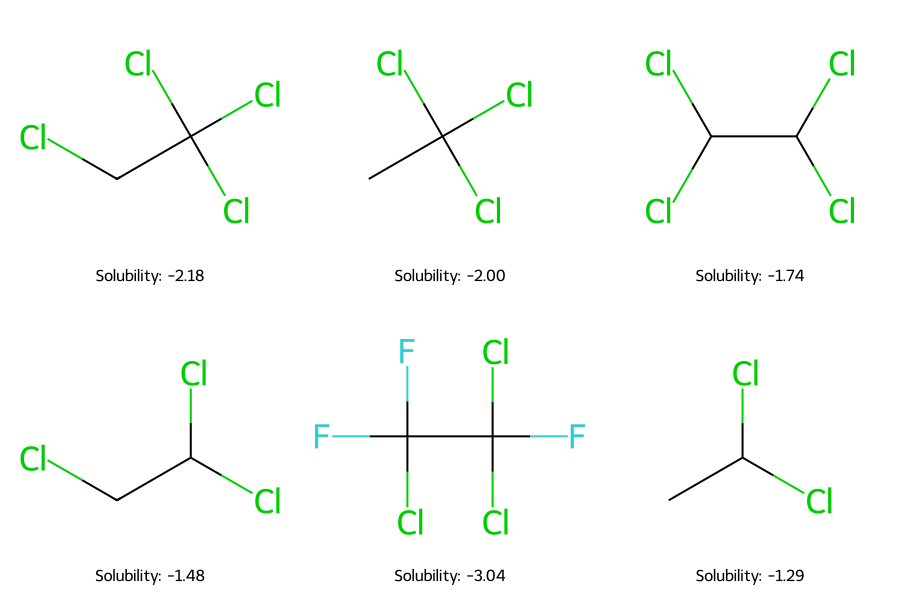

In [ ]:
def visualize_molecules(df, n_molecules=6):
    # Create a list to store the molecule images
    imgs = []
    legends = []

    for idx in range(min(n_molecules, len(df))):

    # TODO (5 MINUTES):
    # For each molecule in the dataset:
    # 1. Retrieve the SMILES string from the current row and store it in a variable called `smiles`.
    # 2. Retrieve the corresponding solubility value and store it in a variable called `solubility`.
    # 3. Convert the SMILES string into an RDKit molecule object using Chem and store it in a variable called `mol`.
    #
    # Hints:
    # - Use the current index (idx) to access the DataFrame row.
    # - Identify the correct column names for SMILES and solubility.
    # - Use an RDKit function to convert SMILES → molecule object.

    # YOUR CODE HERE


    # TODO (Validation):
    # Ensure that `mol` is valid (not None).If it´s not valid skip this iteration to avoid errors in later steps.

    # YOUR CODE HERE


    # Generate 2D coordinates for better visualization
    AllChem.Compute2DCoords(mol)

    # Append the molecule and its legend to the respective lists
    imgs.append(mol)
    legends.append(f'Solubility: {solubility:.2f}')

    # Create a grid of molecule images
    img = Draw.MolsToGridImage(
        imgs,
        legends=legends,  # Add legends with solubility values
        molsPerRow=3,  # Number of molecules per row
        subImgSize=(300, 300),  # Size of each sub-image
        returnPNG=False  # Return as an image object, not PNG
    )
    return img

# Visualize the first 5 molecules in the dataset
img = visualize_molecules(df)
img

## Molecular Descriptors

Molecular descriptors are numerical values that describe the properties of molecules. These descriptors are widely used in cheminformatics and machine learning for tasks such as property prediction, similarity analysis, and clustering.


Let´s check what is a molecule descriptor. First we need to transform SMILES into a molecule object

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

# Convert SMILES to RDKit mol objects
mols = [Chem.MolFromSmiles(x) for x in df['SMILES']]
mols = [x for x in mols if x is not None]
df['mols'] = mols

df.head()



,measured log(solubility:mol/L),SMILES,mols
0,-2.18,ClCC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f2286b3ba70>
1,-2.00,CC(Cl)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f2286504430>
2,-1.74,ClC(Cl)C(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f2286507610>
3,-1.48,ClCC(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f2286505d20>
4,-3.04,FC(F)(Cl)C(F)(Cl)Cl,<rdkit.Chem.rdchem.Mol object at 0x7f2286504ac0>


### Molecular Descriptors in Our Dataset

Using RDKit, we will calculate the following molecular descriptors for the molecules in our dataset:

- **Molecular Weight (g/mol)**: The total molecular weight of the compound.
- **Octanol-Water Partition Coefficient (LogP)**: A measure of the compound's hydrophobicity.
- **Topological Polar Surface Area (TPSA)**: The surface area of polar atoms in the molecule.
- **Number of H-Bond Donors**: The count of hydrogen bond donors in the molecule.
- **Number of H-Bond Acceptors**: The count of hydrogen bond acceptors in the molecule.
- **Ring Count**: The number of rings in the molecular structure.
- **Heavy Atom Count**: The number of non-hydrogen atoms in the molecule.
- **Number of Rotatable Bonds**: The count of bonds that can freely rotate.

These descriptors provide a comprehensive representation of the physicochemical properties of the molecules in our dataset, enabling us to better understand their behavior and predict their solubility.

In [ ]:
# TODO:
# Create a dictionary called `data` that contains molecular descriptors computed from the molecules in `df['mols']`.
#
# Instructions:
# - Include the SMILES strings under the key `'smiles'`.
# - Compute the following descriptors using RDKit:
#   * Molecular Weight
#   * LogP (octanol-water partition coefficient)
#   * TPSA (topological polar surface area)
#   * Number of H-bond donors
#   * Number of H-bond acceptors
#   * Ring count
#   * Heavy atom count
#   * Number of rotatable bonds
#
# Hints:
# - Use list comprehensions to iterate over `df['mols']`.
# - Use the RDKit `Descriptors` module.
# - Each descriptor should be stored as a list.

# YOUR CODE HERE

mol_descriptor_df = pd.DataFrame(data)
mol_descriptor_df['Solubility'] = df['measured log(solubility:mol/L)']  # Change column name to 'Solubility'

# Create descriptor labels for plotting
descriptor_labels = {
    'Solubility': 'Solubility (logS)',
    'MolWt': 'Molecular Weight (g/mol)',
    'LogP': 'Octanol-Water Partition Coefficient (LogP)',
    'TPSA': 'Topological Polar Surface Area (TPSA)',
    'NumHDonors': 'Number of H-Bond Donors',
    'NumHAcceptors': 'Number of H-Bond Acceptors',
    'RingCount': 'Ring Count',
    'HeavyAtomCount': 'Heavy Atom Count',
    'RotatableBonds': 'Number of Rotatable Bonds'
}

mol_descriptor_df = mol_descriptor_df.rename(columns=descriptor_labels)

Let´s see our dataset with molecular descriptors

In [ ]:
mol_descriptor_df.head()

,smiles,Molecular Weight (g/mol),Octanol-Water Partition Coefficient (LogP),Topological Polar Surface Area (TPSA),Number of H-Bond Donors,Number of H-Bond Acceptors,Ring Count,Heavy Atom Count,Number of Rotatable Bonds,Solubility (logS)
0,ClCC(Cl)(Cl)Cl,167.850,2.5954,0.0,0,0,0,6,0,-2.18
1,CC(Cl)(Cl)Cl,133.405,2.3765,0.0,0,0,0,5,0,-2.00
2,ClC(Cl)C(Cl)Cl,167.850,2.5938,0.0,0,0,0,6,1,-1.74
3,ClCC(Cl)Cl,133.405,2.0289,0.0,0,0,0,5,1,-1.48
4,FC(F)(Cl)C(F)(Cl)Cl,187.375,2.9189,0.0,0,0,0,8,1,-3.04


### Distribution of Molecular Descriptors

We can visualize the distribution of the data describing the molecules in our dataset. This will allow us to better understand the physicochemical properties of the molecules and how they are distributed within the dataset. These distributions are useful for identifying potential biases or outliers in the molecular descriptors.

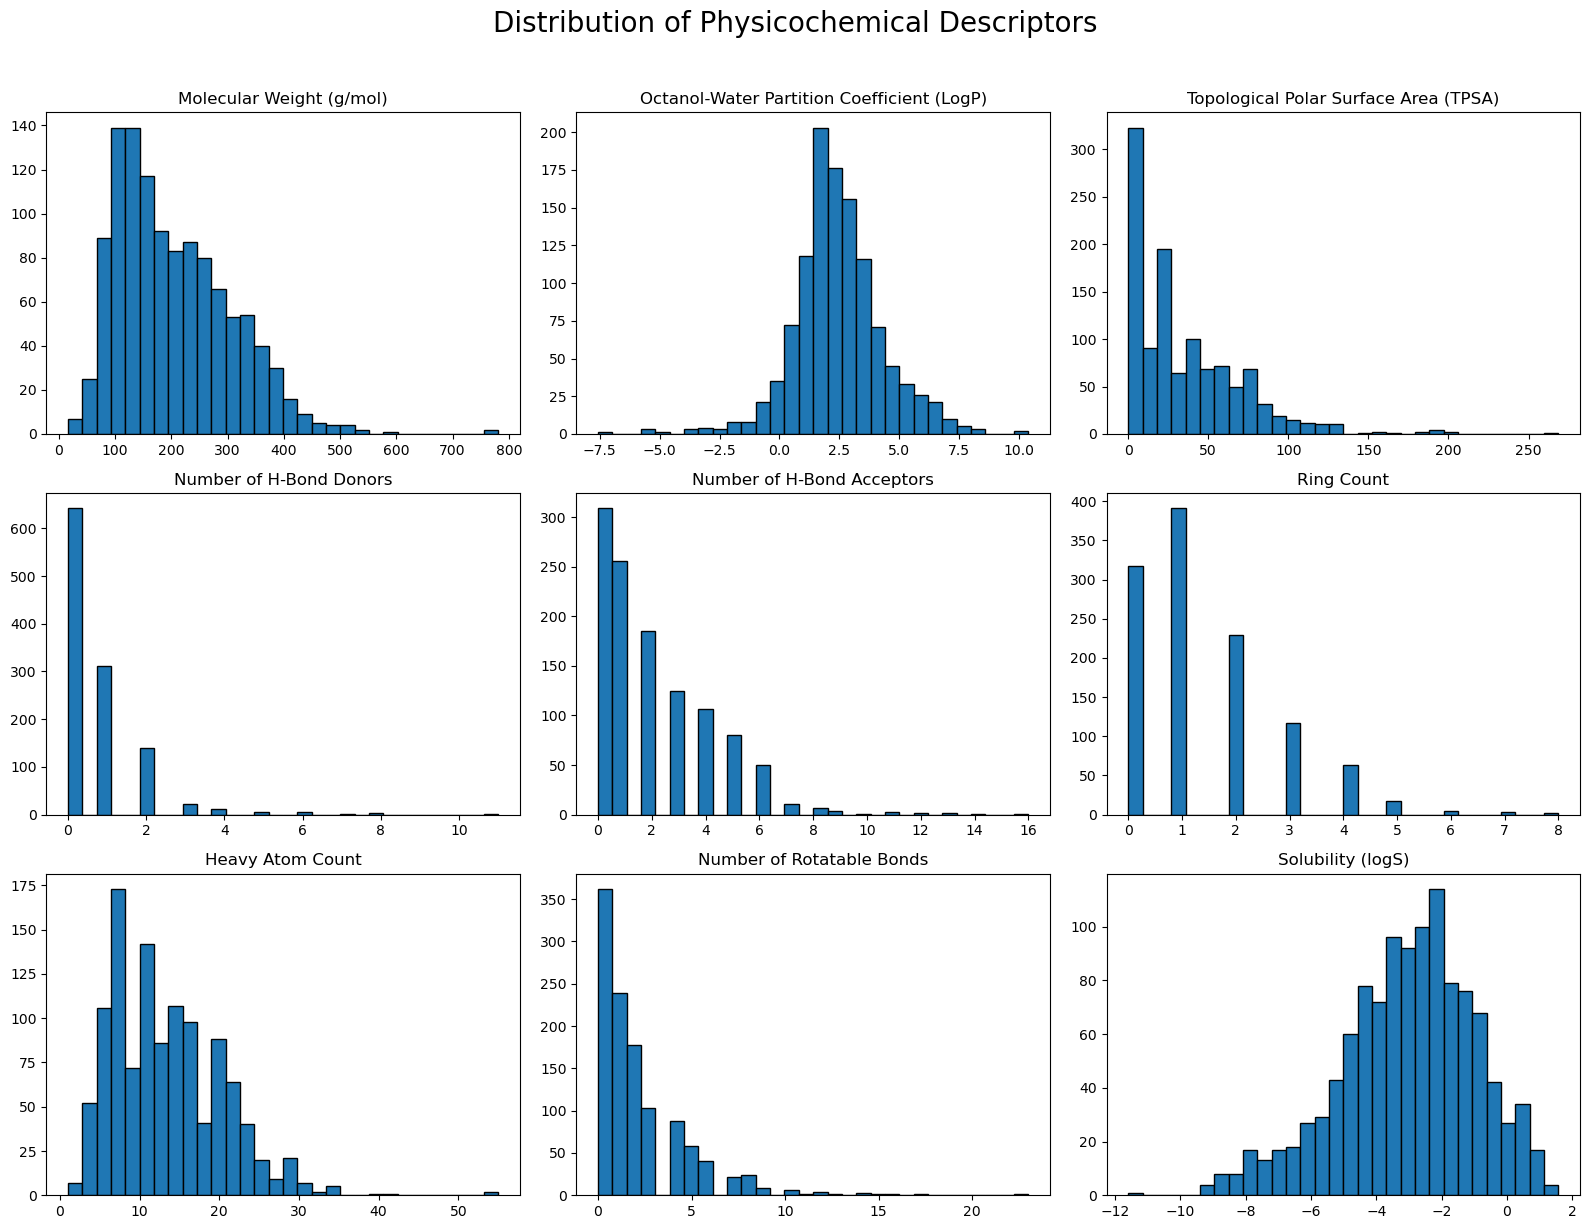

In [ ]:

# TODO:
# Create histograms to visualize the distribution of molecular descriptors.
#
# Instructions:
# - Remove the 'smiles' column before plotting (it is not numeric).
# - Plot histograms for all remaining columns in the DataFrame.
# - Use a reasonable figure size and number of bins.
#
# Hints:
# - Pandas DataFrames have a built-in `.hist()` method.
# - You can customize figure size, bins, and visual style.

# YOUR CODE HERE

Some molecular descriptors are related to others.Pairplot allows us to visualize the relationships between different molecular descriptors and solubility.
This tool is useful for identifying patterns, correlations, and potential trends in the data,
which can help us better understand molecular properties of our dataset.

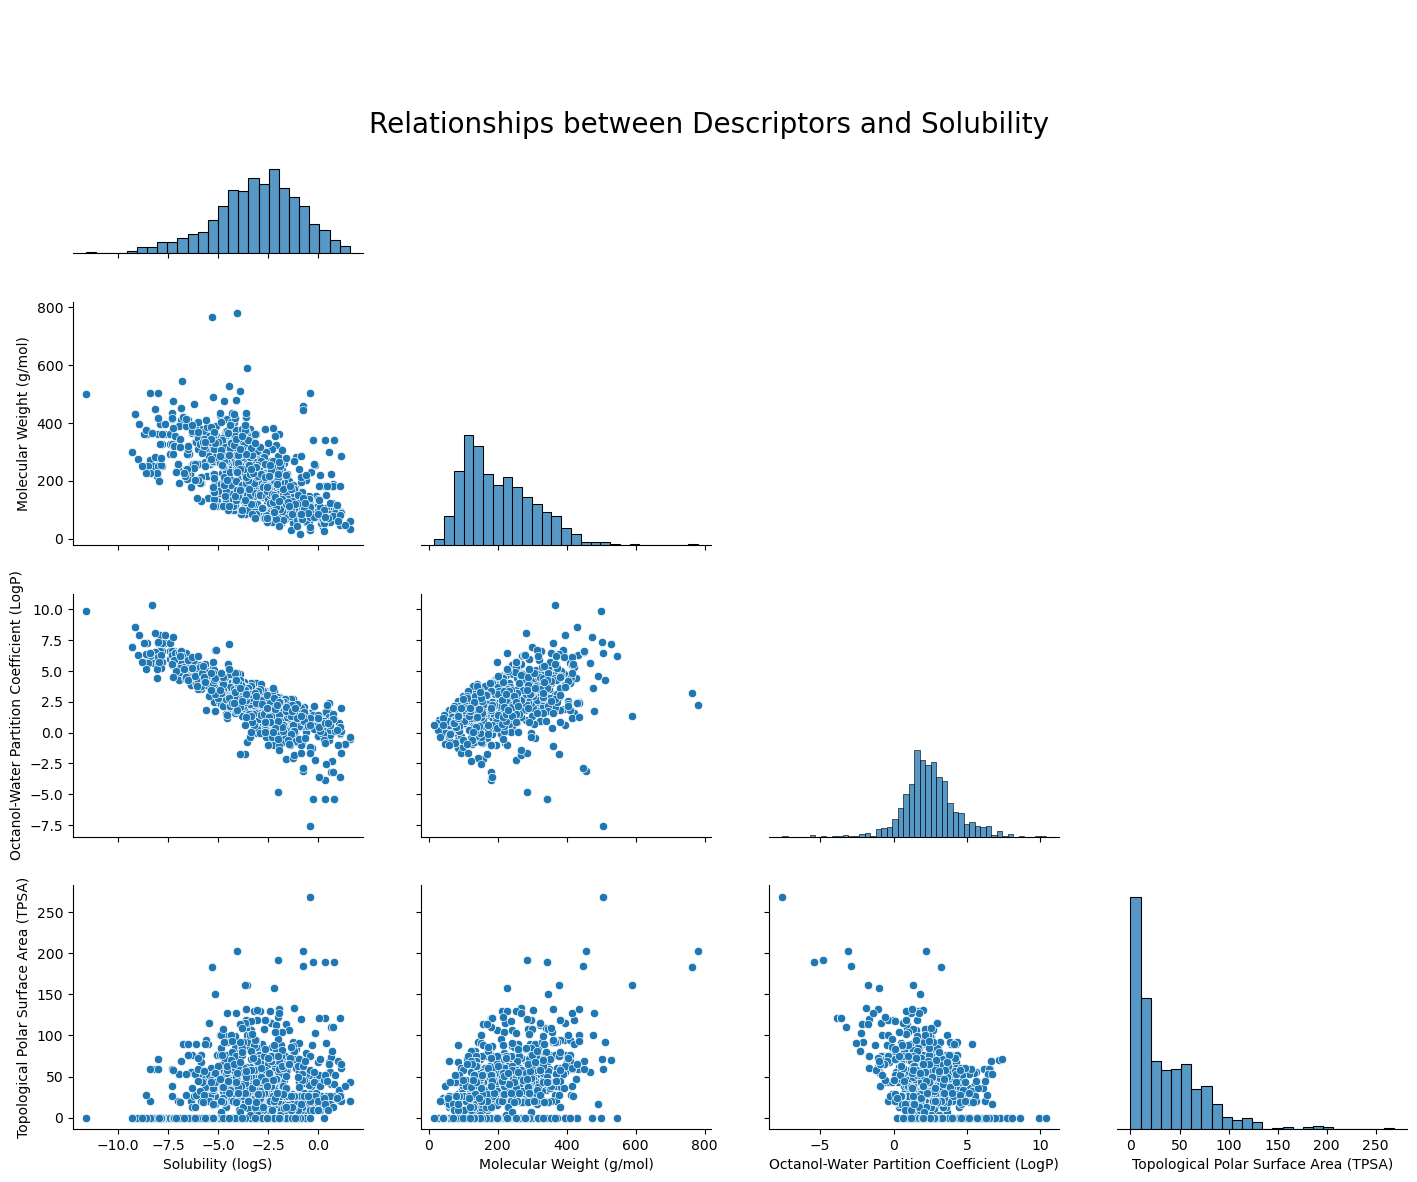

In [ ]:
# Create pairplot with adjusted spacing
sns.pairplot(
    mol_descriptor_df[['Solubility (logS)', 'Molecular Weight (g/mol)',
                      'Octanol-Water Partition Coefficient (LogP)',
                      'Topological Polar Surface Area (TPSA)']],
    corner=True,
    height=3,  # Increase individual plot size
    aspect=1.2,  # Adjust aspect ratio
)

# Adjust layout
plt.subplots_adjust(
    hspace=0.2,  # Increase vertical spacing between subplots
    wspace=0.2   # Increase horizontal spacing between subplots
)

# Add title with adjusted position
plt.suptitle("Relationships between Descriptors and Solubility",
            fontsize=20,
            y=0.9)  # Move title up slightly

plt.show()


In a pairplot, it can be challenging to observe relationships when we have many variables. To simplify this, we can also create a correlation matrix.


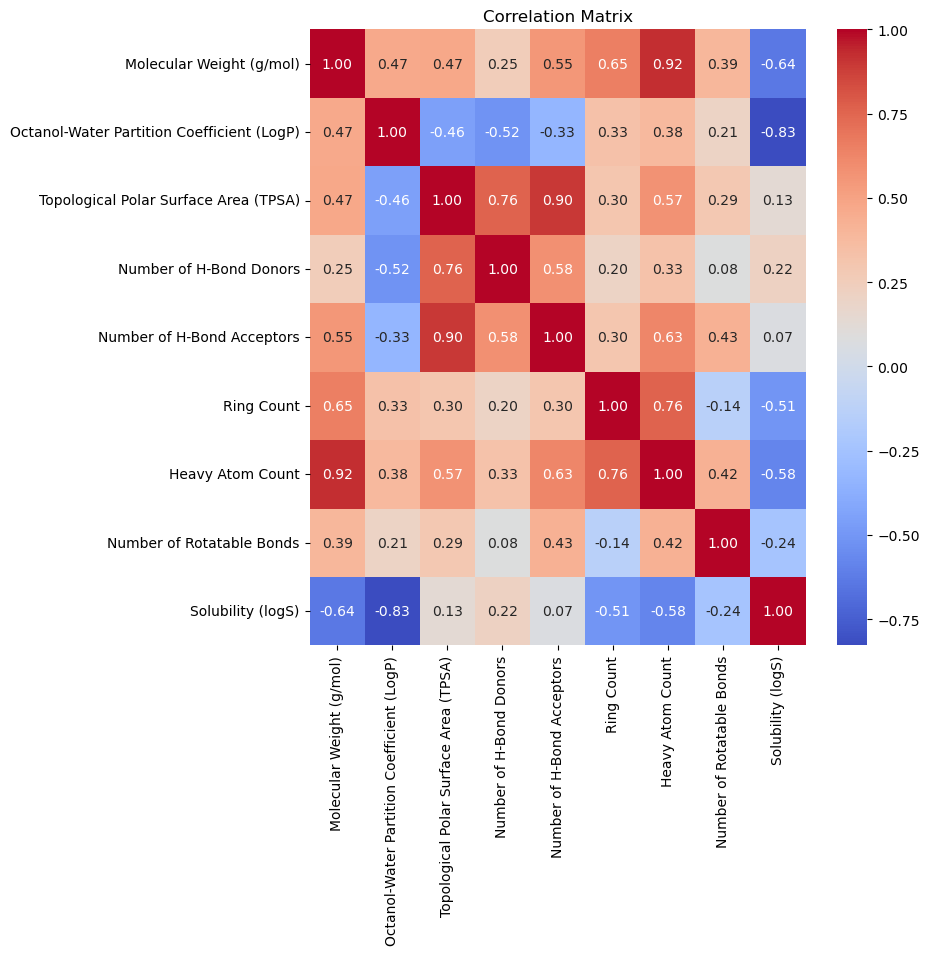

In [ ]:
import numpy as np
numeric_df = mol_descriptor_df.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Let´s check the relevance molecular descriptors with Solubility

| Molecular Property                              | Correlation with logS | Interpretation / Relevance                                                                    |
|-------------------------------------------------|------------------------|-----------------------------------------------------------------------------------------------|
| Octanol-Water Partition Coefficient (LogP)      | **-0.83**              | More lipophilic molecules (higher LogP) tend to be less soluble in water.                    |
| Molecular Weight (g/mol)                        | **-0.64**              | Larger or heavier molecules are generally less water-soluble.                                |
| Heavy Atom Count                                | **-0.58**              | Molecules with more heavy atoms tend to be less soluble.                                     |
| Ring Count                                      | **-0.51**              | Molecules with more ring structures are often less soluble.                                  |
| Number of Rotatable Bonds                       | -0.24                  | Increased flexibility might reduce solubility in this dataset.                               |
| Number of H-Bond Donors                         | 0.22                   | More hydrogen bond donors can slightly increase solubility.                                  |
| Topological Polar Surface Area (TPSA)           | 0.13                   | Polar surface area may improve solubility, but has low correlation here.                    |
| Number of H-Bond Acceptors                      | 0.07                   | Very weak influence on solubility in this dataset.                                            |

📌 Conclusion

The molecular properties most strongly (negatively) correlated with solubility are:

- LogP (lipophilicity)
- Molecular Weight
- Heavy Atom Count
- Ring Count

These features stand out as the most predictive variables for solubility in this dataset, and are key candidates for use in predictive models or molecular design pipelines.


That's a lot of features, isn't it? How can we pass all this information to the deep learning model? In the field of cheminformatics, there are already libraries that help us create **embeddings** that encapsulate this information. For this, we will use **DeepChem**.

A **Featurizer** is a piece of code that transforms raw input data into a processed form suitable for machine learning.


In [ ]:
from deepchem.feat import RDKitDescriptors


smiles_mols = df['SMILES'].values
solubility = df['measured log(solubility:mol/L)'].values

# TODO:
# Initialize an RDKit descriptor featurizer from DeepChem and generate molecular features.
#
# Instructions:
# - Create an instance of `RDKitDescriptors`.
# - Use it to featurize the SMILES strings.
# - Store the result in a variable called `mol_features`.
#
# Hints:
# - Use the `.featurize()` method.

# YOUR CODE HERE

print(f"Number of molecules: {mol_features.shape[1]}")
mol_features = mol_features[:, ~np.isnan(mol_features).any(axis=0)]
print(f"Number of molecular descriptors without invalid values: {mol_features.shape[1]}")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/daniel/miniconda3/envs/biotrAIn/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geomet

Number of molecules: 217
Number of molecular descriptors without invalid values: 217


Now check the data we will work with: solubility and embeding of molecular descriptors

In [ ]:
df['molecular features'] = list(mol_features)
df.drop(columns=['mols','SMILES'], inplace=True)
df.head()

,measured log(solubility:mol/L),molecular features
0,-2.18,"[1.3516441151533922, 2.15541598973672, -2.0035..."
1,-2.00,"[0.7219280948873623, 2.065641219022883, -1.942..."
2,-1.74,"[1.3609640474436813, 2.063775394098705, -1.945..."
3,-1.48,"[1.3787834934861756, 1.8823546186514333, -1.82..."
4,-3.04,"[1.253297578463043, 2.506737605493095, -2.1315..."


## Data Splitting
When developing Deep Learning models, it's crucial to properly split our data to ensure robust evaluation and prevent overfitting. The data is divided into three distinct sets:

### Train/Validation/Test Split
We split our data into three sets with the following distribution:

- **Training Set (80%)**
  - Used to train the model
  - The model learns patterns from this data
  - Weights and biases are adjusted based on this set

- **Validation Set (10%)**
  - Used to tune hyperparameters
  - Helps detect overfitting during training
  - Not used for training, only for evaluation
  - Guides model selection and hyperparameter optimization

- **Test Set (10%)**
  - Used only for final evaluation
  - Never seen during training or tuning
  - Provides unbiased estimate of model performance
  - Simulates real-world performance

### Why Split the Data?
1. **Prevent Overfitting**
   - Keeping test data separate ensures we don't tune our model to specific examples
   - Helps evaluate true generalization ability

2. **Proper Evaluation**
   - Test set provides unbiased performance metrics
   - Validation set helps optimize model without contaminating test data

3. **Model Selection**
   - Validation performance guides architecture and hyperparameter choices
   - Helps choose between different model variants

![Train-Validation-Test Split](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

This splitting strategy is fundamental for developing robust Deep Learning models that can generalize well to new, unseen data.

In [ ]:
from deepchem.splits import RandomSplitter
from deepchem.data import NumpyDataset

# Prepare the data
X = np.array([x for x in df['molecular features']])  # Features
y = df['measured log(solubility:mol/L)'].values.reshape(-1, 1)  # Target reshaped for correct format

# Create the DeepChem dataset
dataset = NumpyDataset(X=X, y=y)

# Use the splitter
# TODO:
# Split the dataset into training, validation, and test sets.
#
# Instructions:
# - Use `RandomSplitter` from DeepChem.
# - Split the dataset into:
#   * 80% training
#   * 10% validation
#   * 10% test
# - Use a fixed random seed for reproducibility as 42.
#
# Hints:
# - Use `.train_valid_test_split()` method.

# YOUR CODE HERE

# Check the dimensions
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(valid_dataset)}")
print(f"Test set size: {len(test_dataset)}")


Training set size: 915
Validation set size: 114
Test set size: 115


# 3. Neural Network Architecture

### Understanding Neural Network Layers

A neural network consists of three main types of layers:

1. **Input Layer**
   - First layer in the network
   - Receives raw features (in our case, molecular descriptors)
   - Number of neurons equals number of input features
   - No computation performed, just passes data forward

2. **Hidden Layers**
   - Layers between input and output
   - Process and transform the data
   - Apply weights, biases, and activation functions
   - Can be multiple layers deep
   - Each neuron connects to all neurons in next layer

3. **Output Layer**
   - Final layer of the network
   - Produces the prediction (in our case, solubility value)
   - Number of neurons matches prediction task
   - One neuron for regression (our case)

<div align="center">
<img src="https://github.com/schwallergroup/ai4chem_course/blob/main/notebooks/03%20-%20Intro%20to%20Deep%20Learning/img/nn_image.png?raw=1" width="500"/>
</div>

### Understanding Layer Depth in Neural Networks
The number of hidden layers significantly impacts a neural network's ability to learn complex, non-linear patterns:

1. **Single Layer Networks**
   - Can only learn linear relationships
   - Limited capacity for complex patterns
   - Example: `y = ax + b`

2. **Two Layer Networks**
   - Can approximate any continuous function
   - Good for simple non-linear patterns
   - Example: Can learn basic curves and patterns

3. **Deep Networks (3+ layers)**
   - Can learn hierarchical features
   - Better at capturing complex non-linear relationships
   - More efficient parameter usage for complex tasks

<div align="center">
<img src="https://vitalflux.com/wp-content/uploads/2022/04/Linearly-vs-Not-linearly-separable-datasets-768x285.png" width="600"/>
</div>

### Our Implementation
We'll experiment with different architectures using grid search:

```python
param_grid = {
    'num_layers': [1, 2, 3],     
    'hidden_size': [256, 512],   
    'learning_rate': [0.001, 0.0001],
    'batch_size': [32, 64]
}
```

### Expected Impact:
- **More Layers**: Better capture of complex molecular relationships
- **More Neurons**: Increased model capacity but risk of overfitting
- **Trade-off**: Deeper networks might be harder to train but could learn better representations

### Why This Matters for Solubility Prediction
Molecular solubility depends on multiple non-linear interactions:
- Hydrogen bonding
- Van der Waals forces
- Conformational changes
- Complex structure-property relationships

A deeper network might better capture these intricate relationships between molecular features and solubility.

## 3.1 Creating a Deep Learning Model

Modern deep learning frameworks like [PyTorch Lightning](https://pytorch-lightning.readthedocs.io/en/stable/index.html) use object-oriented programming to make model creation intuitive and flexible. Before we build our neural network, let's understand the fundamental concept of classes.

### Understanding Classes in Python

A class is like a blueprint that defines:
- What properties (attributes) an object has
- What actions (methods) it can perform

Think of it this way:
- A class is to an object what a blueprint is to a house
- Many houses can be built from the same blueprint
- Each house (instance) can have different:
  - Number of rooms
  - Size
  - Color
  - Utilities

Here's a simple example:

```python
class House:
    def __init__(self, rooms, size, style):
        # Attributes
        self.rooms = rooms    # Like layers in our network
        self.size = size      # Like neurons in each layer
        self.style = style    # Like activation function
        
    def describe(self):
        # Method - what the house can do
        print(f"This {self.style} house has {self.rooms} rooms and is {self.size} sqft")
```

We can create multiple houses (instances) from this class:
```python
    modern_house = House(rooms=3, size=2000, style="modern")
    colonial_house = House(rooms=5, size=3000, style="colonial")

    modern_house.describe()
```
The output should be something like this: ```"This modern house has 3 rooms and is 2000 sqft"```


### From Houses to Neural Networks
Now let's define a NeuralNetwork class.This same concept applies to creating neural networks, a neural network class defines its structure and behavior. Here's how the analogy translates:

| House Blueprint | Neural Network |
|----------------|----------------|
| Rooms | Layers |
| Size | Number of Neurons |
| Style | Activation Functions |
| Description | Predictions |

#### Neural Network Components


### 1. Attributes
- **Learning Rate (`lr`)**:
  - Controls weight update magnitude
  - Default: 1e-3

- **Datasets**:
  - `train_dataset`: Training data
  - `valid_dataset`: Validation data  
  - `test_dataset`: Test data

- **Batch Size**:
  - Number of samples per update
  - Default: 254

- **Loss Tracking**:
  - `train_losses`: Average loss per epoch
  - `val_losses`: Validation loss per epoch
  - `train_epoch_losses`: Individual batch losses
  - `val_epoch_losses`: Individual validation losses

- **Model Architecture**:
  - Input layer: `input_sz` features
  - Hidden layers: `num_layers` with `hidden_sz` neurons
  - Output layer: Single neuron (regression)
  - Activation: ReLU between layers

### 2. Methods
- **Forward Pass (`forward`)**:
  - Takes input tensor x
  - Passes through model layers
  - Returns flattened predictions

- **Training (`training_step`)**:
  - Processes batch of data
  - Computes predictions and loss
  - Logs training metrics
  - Stores loss for learning curves

- **Validation (`validation_step`)**:
  - Evaluates model on validation data
  - Computes validation loss
  - No weight updates
  - Tracks performance

- **Testing (`test_step`)**:
  - Final model evaluation
  - Computes test MSE
  - No weight updates

- **Optimization (`configure_optimizers`)**:
  - Uses Adam optimizer
  - Configurable learning rate

- **Data Loading**:
  - `train_dataloader`: Training data with shuffling
  - `val_dataloader`: Validation data, no shuffle
  - `test_dataloader`: Test data, no shuffle

In [ ]:
import os
import torch
import wandb
from torch import nn
import torch.nn.functional as F
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from pytorch_lightning.loggers import WandbLogger
from torch.utils.data import TensorDataset

In [ ]:
class NeuralNetwork(pl.LightningModule):
    """
    Neural network model for molecular solubility prediction using PyTorch Lightning.

    Attributes:
        lr (float): Learning rate for optimizer (default: 1e-3)
        train_dataset: Training dataset with molecular features and solubility values
        valid_dataset: Validation dataset
        test_dataset: Test dataset
        batch_size (int): Number of samples per batch (default: 254)
        train_losses (list): Track average loss per epoch during training
        val_losses (list): Track average loss per epoch during validation
        train_epoch_losses (list): Store individual batch losses within an epoch
        val_epoch_losses (list): Store individual validation losses within an epoch
        model (nn.Sequential): Neural network architecture constructed dynamically

    Architecture:
        - Input Layer: Takes molecular descriptors (input_sz features)
        - Hidden Layers: num_layers with hidden_sz neurons each
        - ReLU activation between layers
        - Output Layer: Single neuron for solubility prediction
    """
    def __init__(self, input_sz, hidden_sz, num_layers, train_dataset, valid_dataset, test_dataset, batch_size=254, lr=1e-3):
        """
        Initialize model architecture and training parameters.

        Args:
            input_sz (int): Number of input features (molecular descriptors)
            hidden_sz (int): Number of neurons in hidden layers
            num_layers (int): Number of hidden layers
            train_dataset: Training data
            valid_dataset: Validation data
            test_dataset: Test data
            batch_size (int): Samples per batch (default: 254)
            lr (float): Learning rate (default: 1e-3)
        """
        super().__init__()
        self.lr = lr  # Learning rate
        self.train_dataset = train_dataset  # Training dataset
        self.valid_dataset = valid_dataset  # Validation dataset
        self.test_dataset = test_dataset  # Test dataset
        self.batch_size = batch_size  # Batch size for data loaders

        # Initialize lists to store losses for training and validation
        self.train_losses = []
        self.val_losses = []
        self.train_epoch_losses = []
        self.val_epoch_losses = []

        # Dynamically construct the neural network based on num_layers
        # TODO:
        # Build the neural network architecture dynamically.
        #
        # Instructions:
        # - Create a list called `layers`.
        # - Add an input layer that maps from `input_sz` to `hidden_sz`.
        # - Add a ReLU activation.
        # - Add additional hidden layers based on `num_layers`.
        # - Add a final output layer with a single neuron.
        #
        # Hints:
        # - Use `nn.Linear` for fully connected layers.
        # - Use `nn.ReLU` for activation.
        # - The output layer should map to 1 value (regression task).

        # YOUR CODE HERE

        # Create the model as a sequential container
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x (torch.Tensor): Input tensor of molecular descriptors

        Returns:
            torch.Tensor: Predicted solubility values (flattened)
        """
        return self.model(x).flatten()

    def training_step(self, batch, batch_idx):
        """
        Execute single training step on one batch.

        Args:
            batch (tuple): Batch of (features, targets)
            batch_idx (int): Index of current batch

        Returns:
            torch.Tensor: Computed MSE loss
        """
        x, y = batch  # Unpack features and targets
        z = self.model(x)  # Forward pass
        loss = F.mse_loss(z, y)  # Compute mean squared error loss
        self.log("Train loss", loss, on_epoch=True, prog_bar=True)  # Log training loss

        # Store the loss for training curve visualization
        self.train_epoch_losses.append(loss.detach())
        return loss

    def validation_step(self, batch, batch_idx):
        """
        Execute single validation step.

        Args:
            batch (tuple): Batch of (features, targets)
            batch_idx (int): Index of current batch

        Returns:
            torch.Tensor: Computed validation MSE loss
        """
        x, y = batch  # Unpack features and targets
        z = self.model(x)  # Forward pass
        loss = F.mse_loss(z, y)  # Compute mean squared error loss
        self.log("Valid MSE", loss, on_epoch=True, prog_bar=True)  # Log validation loss

        # Store the loss for validation curve visualization
        self.val_epoch_losses.append(loss.detach())
        return loss

    def test_step(self, batch, batch_idx):
        """
        Execute single test step.

        Args:
            batch (tuple): Batch of (features, targets)
            batch_idx (int): Index of current batch
        """
        x, y = batch  # Unpack features and targets
        z = self.model(x)  # Forward pass
        loss = F.mse_loss(z, y)  # Compute mean squared error loss
        self.log("Test MSE", loss)  # Log test loss

    def configure_optimizers(self):
        """
        Configure optimizer for training.

        Returns:
            torch.optim.Optimizer: Adam optimizer with specified learning rate
        """
        return torch.optim.Adam(self.parameters(), lr=self.lr)

    def train_dataloader(self):
        """
        Create training data loader.

        Returns:
            DataLoader: Training data loader with shuffling enabled
        """
        X = torch.FloatTensor(self.train_dataset.X)  # Convert features to tensor
        y = torch.FloatTensor(self.train_dataset.y)  # Convert targets to tensor
        return DataLoader(
            TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=False
        )

    def val_dataloader(self):
        """
        Create validation data loader.

        Returns:
            DataLoader: Validation data loader
        """
        X = torch.FloatTensor(self.valid_dataset.X)  # Convert features to tensor
        y = torch.FloatTensor(self.valid_dataset.y)  # Convert targets to tensor
        return DataLoader(
            TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=False
        )

    def test_dataloader(self):
        """
        Create test data loader.

        Returns:
            DataLoader: Test data loader
        """
        X = torch.FloatTensor(self.test_dataset.X)  # Convert features to tensor
        y = torch.FloatTensor(self.test_dataset.y)  # Convert targets to tensor
        return DataLoader(
            TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=False
        )

    def on_train_epoch_end(self):
        """
        Calculate and save the average training loss at the end of each epoch.
        Clears the list of batch losses for the current epoch to prepare for the next epoch.
        """
        avg_loss = torch.stack(self.train_epoch_losses).mean()  # Compute average loss for the epoch
        self.train_losses.append(avg_loss.item())  # Append the average loss to the training losses list
        self.train_epoch_losses.clear()  # Clear the batch losses for the current epoch

    def on_validation_epoch_end(self):
        """
        Calculate and save the average validation loss at the end of each epoch.
        Clears the list of batch losses for the current epoch to prepare for the next epoch.
        """
        avg_loss = torch.stack(self.val_epoch_losses).mean()  # Compute average loss for the epoch
        self.val_losses.append(avg_loss.item())  # Append the average loss to the validation losses list
        self.val_epoch_losses.clear()  # Clear the batch losses for the current epoch

## PyTorch Lightning Trainer

The Trainer is a high-level interface that handles:
1. Training loop management
2. Validation checks
3. Early stopping
4. GPU acceleration
5. Logging and monitoring

Let's implement grid search to find optimal hyperparameters:

### Hyperparameters Explained

1. **Learning Rate (lr)**:
   - Controls how much we adjust weights in each step
   - Too high: unstable training
   - Too low: slow training

2. **Batch Size**:
   - Number of samples processed before weight update
   - Larger: more stable, but needs more memory
   - Smaller: more noise, but can help escape local minima

3. **Hidden Size**:
   - Number of neurons in hidden layers
   - Larger: more capacity to learn, but risk of overfitting
   - Smaller: may underfit if too small

4. **Number of Epochs**:
   - How many times we go through the entire dataset
   - Too few: underfitting
   - Too many: risk of overfitting

### Root Mean Square Error (RMSE)
RMSE is our main evaluation metric:
- Calculated as: √(mean((predicted - actual)²))
- Gives more weight to larger errors
- In same units as our target (log mol/L)


In [ ]:
def grid_search_cv(param_grid):
    best_rmse = float('inf')
    best_params = None
    results = []

    for lr in param_grid['learning_rate']:
        for hidden_size in param_grid['hidden_size']:
            for batch_size in param_grid['batch_size']:
                for num_layers in param_grid['num_layers']:
                    print(f'\nTesting: lr={lr}, hidden_size={hidden_size}, batch_size={batch_size}, num_layers={num_layers}')

                    model = NeuralNetwork(
                        input_sz=len(train_dataset.X[1]),
                        hidden_sz=hidden_size,
                        num_layers=num_layers,
                        train_dataset=train_dataset,
                        valid_dataset=valid_dataset,
                        test_dataset=test_dataset,
                        lr=lr,
                        batch_size=batch_size
                    )

                    trainer = pl.Trainer(
                        max_epochs=50,
                        logger=False,
                        enable_progress_bar=True
                    )

                    trainer.fit(model)
                    test_results = trainer.test(ckpt_path="best")[0]
                    current_rmse = test_results["Test MSE"] ** 0.5

                    results.append({
                        'lr': lr,
                        'hidden_size': hidden_size,
                        'batch_size': batch_size,
                        'num_layers': num_layers,
                        'rmse': current_rmse
                    })

                    if current_rmse < best_rmse:
                        best_rmse = current_rmse
                        best_params = {
                            'lr': lr,
                            'hidden_size': hidden_size,
                            'batch_size': batch_size,
                            'num_layers': num_layers
                        }



    return pd.DataFrame(results), best_params


# TODO:
# Experiment with different hyperparameter values for the neural network.
# Define a dictionary called `param_grid` containing the hyperparameters to explore.
#
# Instructions:
# - The dictionary should include the following keys:
#   * 'learning_rate'
#   * 'hidden_size'
#   * 'batch_size'
#   * 'num_layers'
#
# - Each key should map to a list of values to try during grid search.
# - Modify the values inside `param_grid` to explore different configurations.
# - Try changing:
#   * Learning rate (e.g., 1e-2, 1e-3, 1e-4)
#   * Hidden layer size (e.g., 128, 256, 512)
#   * Batch size (e.g., 16, 32, 64)
#   * Number of layers (e.g., 1, 2, 3)
#
# Goal:
# - Identify which combination of hyperparameters gives the lowest RMSE.
#
# Tip:
# - Start with small grids to reduce training time.



# Run the grid search with the defined parameter grid
results_df, best_params = grid_search_cv(param_grid)

# Display the results of the grid search
print('\nGrid Search Results:')
print(results_df.sort_values('rmse'))  # Sort results by RMSE
print('\nBest parameters:')
print(best_params)  # Print the best hyperparameter configuration

# Reflection / Discussion:
- Which hyperparameter combination gave you the best RMSE?
- How did your choice of hyperparameter ranges affect the results?
- If you had more computational time, how would you expand your search?

# Class activity:
- Share your `param_grid` and best results with the class.
- Compare strategies: who explored wider vs. more focused ranges?

## Training with Best Parameters

Now let's train our final model with the best parameters found:

In [ ]:
# Create final model with best parameters
final_model = NeuralNetwork(
    input_sz=len(train_dataset.X[1]),
    hidden_sz=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    test_dataset=test_dataset,
    lr=best_params['lr'],
    batch_size=best_params['batch_size']
)

# Train final model
trainer = pl.Trainer(
    max_epochs=150,
    logger=False,
    enable_progress_bar=True
)

trainer.fit(final_model)
final_results = trainer.test(ckpt_path="best")

# Calculate and display final RMSE
final_rmse = final_results[0]["Test MSE"] ** 0.5
print(f'\nFinal Model RMSE: {final_rmse:.4f}')

print("\n✓ Training completed!")
print(f"  Learning Rate: {best_params['lr']}")
print(f"  Hidden Size: {best_params['hidden_size']}")
print(f"  Batch Size: {best_params['batch_size']}")
print(f"  Num Layers: {best_params['num_layers']}")

## 5.Model Analysis

Let's analyze our model's performance through different visualizations:

### 5.1 Learning Curves
The training and validation loss curves help us understand how the model learned over time:

- **Training Loss**: Shows how well the model fits the training data
- **Validation Loss**: Indicates how well the model generalizes to unseen data

A good model should show:
- Decreasing losses over time
- Small gap between training and validation curves
- No significant oscillations
- Signs of convergence

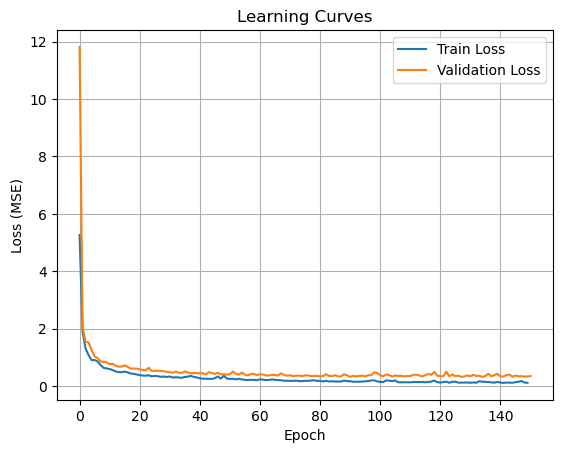

In [ ]:
import matplotlib.pyplot as plt

plt.plot(final_model.train_losses, label='Train Loss')
plt.plot(final_model.val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()


### 5.2 Prediction Performance Analysis

Let's evaluate how well our model performs on the test set by comparing predicted vs actual solubility values. We'll analyze:

1. **Scatter Plot**:
   - Visual representation of predictions against actual values
   - Perfect predictions would lie on the diagonal line
   - Points above the line indicate overestimation
   - Points below the line indicate underestimation


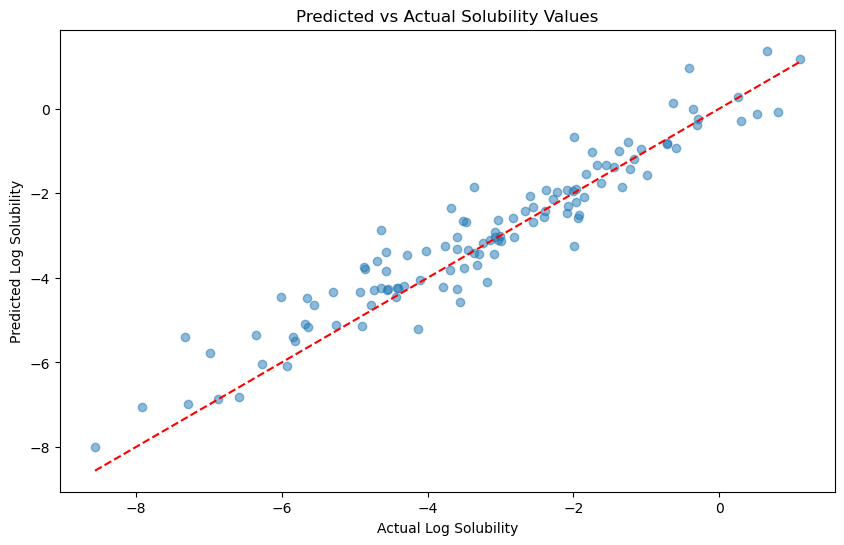

In [ ]:
# Get predictions on test set
test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(test_dataset.X),
        torch.FloatTensor(test_dataset.y)
    ),
    batch_size=len(test_dataset),
    shuffle=False
)
# TODO:
# Generate predictions using the trained model on the test set.
#
# Instructions:
# - Convert the test features into a tensor called `X_test_tensor`.
# - Convert the test targets into a tensor called `y_test_tensor`.
# - Use the trained model (`final_model`) to generate predictions.
# - Store the predictions in a variable called `predictions`.
# - Convert the predictions to a NumPy array.
#
# Hints:
# - Use `torch.FloatTensor` for conversion.
# - Use `.detach().numpy()` to convert from tensor to NumPy.

# YOUR CODE HERE

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(test_dataset.y, predictions, alpha=0.5)
plt.plot(
    [min(test_dataset.y), max(test_dataset.y)],
    [min(test_dataset.y), max(test_dataset.y)],
    'r--'
)
plt.xlabel('Actual Log Solubility')
plt.ylabel('Predicted Log Solubility')
plt.title('Predicted vs Actual Solubility Values')
plt.show()


2. **Error Statistics**:
   - Mean Error: Shows systematic bias in predictions
   - Standard Deviation: Indicates prediction consistency
   - Median Error: Robust measure of central tendency

In [ ]:

# Calculate error statistics
errors = predictions - test_dataset.y
print('\nError Statistics:')
print(f'Mean Error: {np.mean(errors):.4f}')
print(f'Standard Deviation of Error: {np.std(errors):.4f}')
print(f'Median Error: {np.median(errors):.4f}')


Error Statistics:
Mean Error: 0.2207
Standard Deviation of Error: 2.7133
Median Error: 0.1952


In [ ]:
# Get predictions on the test set

# Create a DataLoader for the entire test set (no shuffling, single batch)
test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(test_dataset.X),  # Convert test features to FloatTensor
        torch.FloatTensor(test_dataset.y)   # Convert test labels to FloatTensor
    ),
    batch_size=len(test_dataset),  # Load the entire test set in one batch
    shuffle=False
)

# Extract the full batch of test inputs and labels
X_test_tensor, y_test_tensor = next(iter(test_loader))

# Use the trained model to get predictions (detach from graph and convert to NumPy)
predictions = final_model(X_test_tensor).detach().numpy()

# Ensure the prediction shape is correct: reshape to (n_samples, 1)
predictions = predictions.reshape(-1, 1)  # Example: (113, 1)

# Extract true test labels (already assumed to be in shape (n_samples, 1))
test_y = test_dataset.y

# Compute the prediction errors (difference between predicted and true values)
errors = predictions - test_y

# Print the shapes of all arrays to verify consistency
print("Predictions shape:", predictions.shape)
print("Test y shape:", test_y.shape)
print("Errors shape:", errors.shape)

### 5.1. Error Analysis Based on Molecular Descriptors

#### What do we want to understand?

We aim to investigate whether the model systematically struggles with certain types of molecules (e.g., highly polar or highly lipophilic) by analyzing the relationship between prediction errors and molecular descriptors.


In [ ]:
# Explainability Analysis: Error vs Molecular Descriptors

# 1. Load the original dataset and create molecular objects before the split
df_original = pd.read_csv('data/ESOL.csv')
df_original.drop(columns=['Compound ID','ESOL predicted log(solubility:mol/L)'], inplace=True)
mols = [Chem.MolFromSmiles(x) for x in df_original['SMILES']]

# 2. Obtain the indices of the test set (using the same seed as in the original split)
train_inds, valid_inds, test_inds = splitter.split(
    dataset=dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1,
    seed=42
)

# 3. Extract only the molecules from the test set
test_mols = [mols[i] for i in test_inds]

# 4. Calculate descriptors only for the test set molecules
test_descriptors = {
    'MolWt': [Descriptors.MolWt(m) for m in test_mols],  # Molecular Weight
    'LogP': [Descriptors.MolLogP(m) for m in test_mols],  # Octanol-Water Partition Coefficient
    'TPSA': [Descriptors.TPSA(m) for m in test_mols],  # Topological Polar Surface Area
    'NumHDonors': [Descriptors.NumHDonors(m) for m in test_mols],  # Number of H-Bond Donors
    'NumHAcceptors': [Descriptors.NumHAcceptors(m) for m in test_mols],  # Number of H-Bond Acceptors
    'RingCount': [Descriptors.RingCount(m) for m in test_mols],  # Number of Rings
    'HeavyAtomCount': [Descriptors.HeavyAtomCount(m) for m in test_mols],  # Number of Heavy Atoms
    'RotatableBonds': [Descriptors.NumRotatableBonds(m) for m in test_mols]  # Number of Rotatable Bonds
}

# 5. Create a DataFrame with the descriptors and prediction errors
desc_df = pd.DataFrame(test_descriptors)
desc_df['error'] = errors.flatten()  # Use the prediction errors calculated earlier
desc_df.head()


,MolWt,LogP,TPSA,NumHDonors,NumHAcceptors,RingCount,HeavyAtomCount,RotatableBonds,error
0,295.336,4.86180,43.14,0,2,1,14,1,0.722116
1,392.467,1.89570,94.83,3,5,4,28,2,-0.549865
2,204.010,2.29120,0.00,0,0,1,7,0,-0.034004
3,266.304,2.65122,58.12,1,4,4,20,1,-0.948491
4,157.556,2.24820,43.14,0,2,1,10,1,0.123370


Perform correlation analysis in molecular descriptors

In [ ]:
# 6. Correlation analysis
correlation = desc_df.corr()['error'].sort_values()
print("\nCorrelations between error and molecular descriptors:")
print("----------------------------------------------------")
print("Top 5 descriptors most positively correlated:")
print(correlation.tail(5))
print("\nTop 5 descriptors most negatively correlated:")
print(correlation.head(5))



Correlations between error and molecular descriptors:
----------------------------------------------------
Top 5 descriptors most positively correlated:
NumHAcceptors     0.230673
HeavyAtomCount    0.257702
RotatableBonds    0.262370
MolWt             0.327427
error             1.000000
Name: error, dtype: float64

Top 5 descriptors most negatively correlated:
NumHDonors       0.072846
RingCount        0.082076
LogP             0.087158
TPSA             0.142606
NumHAcceptors    0.230673
Name: error, dtype: float64


Plot the 3 most influential descriptors on the error


Analyzing the 3 most influential descriptors on the error:


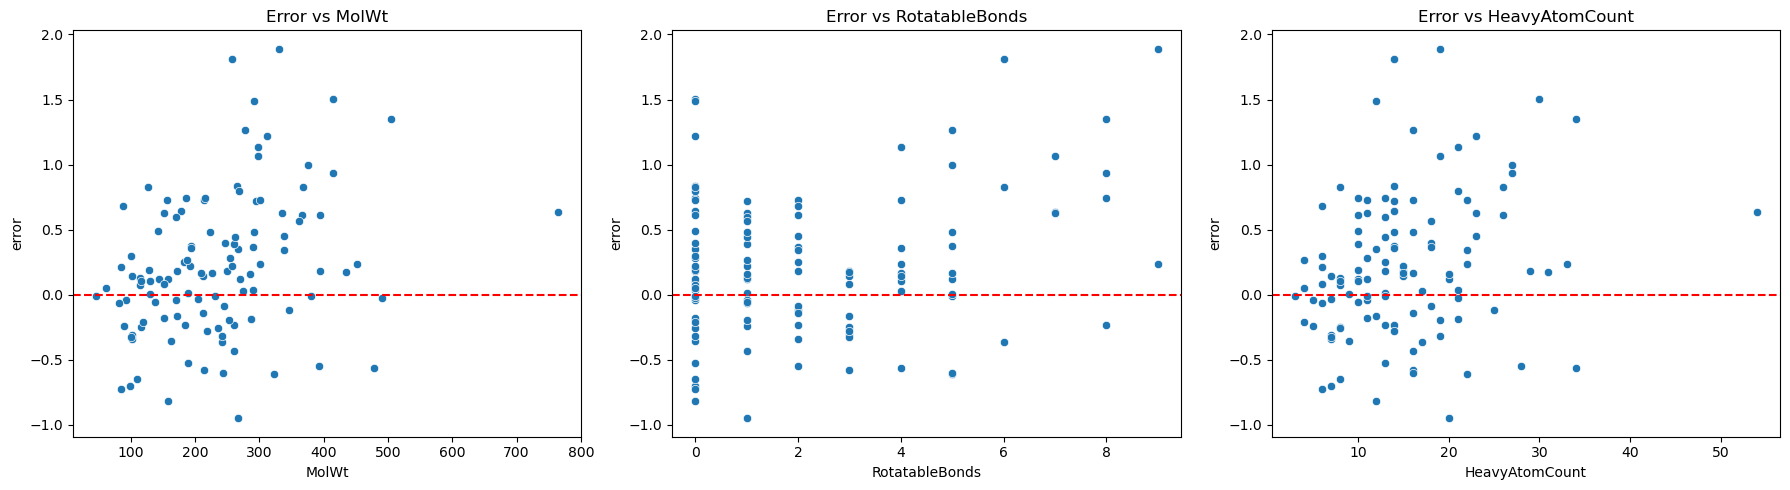

In [ ]:
# 7. Visualization
top_corr = correlation.abs().sort_values(ascending=False).drop('error').head(3).index
print("\nAnalyzing the 3 most influential descriptors on the error:")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, desc in enumerate(top_corr):
    sns.scatterplot(data=desc_df, x=desc, y='error', ax=axes[i])
    axes[i].axhline(0, color='red', linestyle='--')  # Add a horizontal line at y=0
    axes[i].set_title(f'Error vs {desc}')

plt.tight_layout()
plt.show()


## TODO
 Analyze the relationship between molecular descriptors and prediction error.

 Instructions:
 - Observe the scatter plots of error vs each descriptor.
 - Identify any visible patterns or trends.

# Final Reflection

Before reading the interpretation below, answer the following questions based on your analysis:

- Which descriptor showed the strongest relationship with prediction error?
- Did the model tend to overestimate or underestimate solubility?
- For which type of molecules (e.g., polar, non-polar, flexible) did the model perform worse?
- What is one possible reason for this behavior?

## 6. Biological Interpretation of Prediction Errors

### Correlation Between Molecular Descriptors and Prediction Errors

To understand the biological relevance of the prediction errors, we analyzed their correlation with various molecular descriptors.

#### 1. **RingCount** (Correlation ≈ −0.25)
- **Meaning**: Total number of rings (aromatic or saturated) present in the molecular structure.
- **Observation**: Higher ring counts are associated with **negative prediction errors** (i.e., solubility overestimated).
- **Biological Insight**: Polycyclic structures tend to be rigid and hydrophobic, reducing aqueous solubility. The model appears to **underestimate this effect**, possibly due to insufficient representation of fused-ring compounds such as steroids or macrocycles in the training set.

#### 2. **RotatableBonds** (Correlation ≈ +0.15)
- **Meaning**: Number of flexible bonds that can rotate freely, reflecting conformational freedom.
- **Observation**: Molecules with more rotatable bonds tend to show **positive prediction errors** (i.e., solubility underestimated).
- **Biological Insight**: Conformational flexibility allows molecules to adopt orientations favorable for hydration. The model appears to **undervalue this contribution**, leading to systematic underestimation of solubility in highly flexible compounds.

#### 3. **HeavyAtomCount** (Correlation ≈ −0.11)
- **Meaning**: Total number of non-hydrogen atoms, serving as a proxy for overall molecular size.
- **Observation**: Larger molecules tend to show **negative prediction errors** (i.e., solubility overestimated).
- **Biological Insight**: As molecular size increases, hydrophobic surface area grows and solubility decreases. The model appears to **underestimate this size penalty**, particularly for large drug-like molecules.

- Suggests the model **overpredicts solubility** for rigid, polycyclic compounds while **underpredicting** it for large flexible molecules.


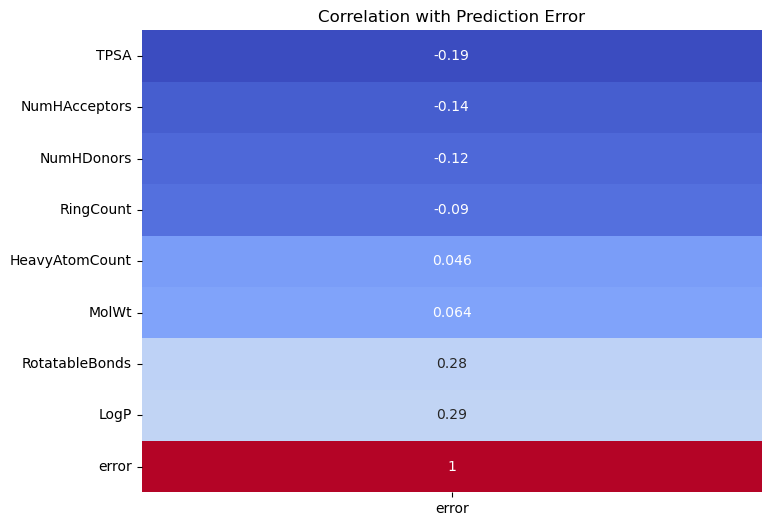

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = desc_df.corr(numeric_only=True)['error'].sort_values()
plt.figure(figsize=(8, 6))
sns.heatmap(corr.to_frame(), annot=True, cmap="coolwarm", cbar=False)
plt.title('Correlation with Prediction Error')
plt.show()
